In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\DR ALI\Downloads\crop_yield.csv")
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  str    
 1   Soil_Type               1000000 non-null  str    
 2   Crop                    1000000 non-null  str    
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  str    
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), str(4)
memory usage: 82.0 MB


In [4]:
df.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
numeric_cols = df.select_dtypes(include='number').columns

outlier_cols = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    if len(outliers) > 0:
        outlier_cols.append(col)
    outliers_count=len(outlier_cols)
    total_rows=len(df)

print("Columns with outliers:")
print(outlier_cols)
outliers_percentage = (outliers_count / total_rows) * 100

print(f"نسبة الـ Outliers هي: {outliers_percentage:.2f}%")

Columns with outliers:
['Yield_tons_per_hectare']
نسبة الـ Outliers هي: 0.00%


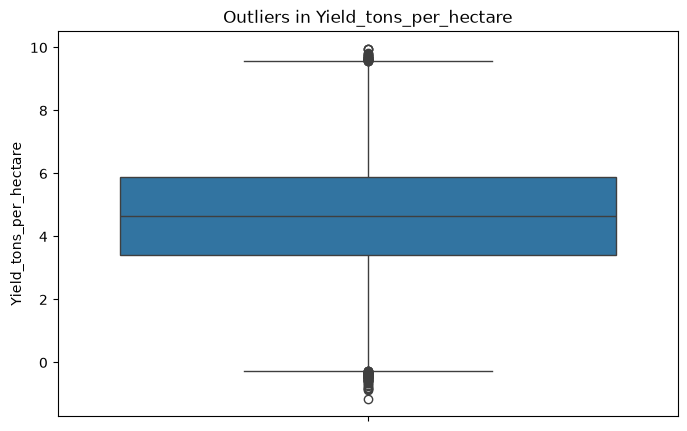

In [7]:
for col in outlier_cols:
    
    plt.figure(figsize=(8, 5))

    sns.boxplot(data=df, y=col)

    plt.title(f'Outliers in {col}')
    plt.ylabel(col)

    plt.show()

In [8]:
df[outlier_cols] =df[outlier_cols].clip(lower=lower, upper=upper, axis=1)


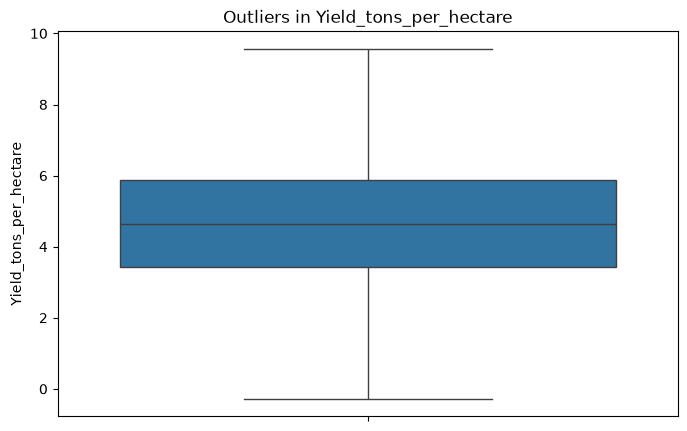

In [9]:
for col in outlier_cols:
    
    plt.figure(figsize=(8, 5))

    sns.boxplot(data=df, y=col)

    plt.title(f'Outliers in {col}')
    plt.ylabel(col)

    plt.show()

In [10]:
x=df.drop('Yield_tons_per_hectare',axis=1)
y=df['Yield_tons_per_hectare']

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [12]:
x_train.select_dtypes(include='str').columns

Index(['Region', 'Soil_Type', 'Crop', 'Weather_Condition'], dtype='str')

In [13]:
cat_cols = x_train.select_dtypes(include='str').columns

x_train = pd.get_dummies(x_train, columns=cat_cols)

x_test = pd.get_dummies(x_test, columns=cat_cols)

x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

In [14]:
replacement_dict = {
'true': 1,
'false': 0,
'True': 1,
'False': 0
}

x_train[['Fertilizer_Used','Irrigation_Used']] = x_train[['Fertilizer_Used','Irrigation_Used']].replace(replacement_dict)
x_test[['Fertilizer_Used','Irrigation_Used']] = x_test[['Fertilizer_Used','Irrigation_Used']].replace(replacement_dict)

In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [16]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](24,)","[ 1.3 , 0.14, 0.75,...,-0. , 0. ,-0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.649
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,24
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(20)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](24,)","[1095.67,1095.33,1033.08,..., 0. , 0. , 0. ]"


In [17]:
y_pred=model.predict(x_test)

In [18]:
from sklearn.metrics import r2_score, mean_squared_error

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print(f'MSE : {mse}')
print(f'R2 Score : {r2}')

MSE : 0.25072649747728987
R2 Score : 0.9130263021416193


In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# ضبط إعدادات الصفحة
st.set_page_config(
    page_title="تطبيق التنبؤ بإنتاجية المحاصيل الزراعية",
    page_icon="🌾",
    layout="wide"
)

st.title("🌾 تطبيق التنبؤ بإنتاجية المحاصيل (Crop Yield Prediction)")
st.markdown("---")

# تحميل النموذج والأعمدة المعالجة
@st.cache_resource
def load_model_assets():
    try:
        model = joblib.load("xgb_model.pkl")
        columns = joblib.load("xgb_columns.pkl")
        return model, columns
    except Exception as e:
        st.error(f"حدث خطأ أثناء تحميل الملفات: {e}")
        return None, None

model, model_columns = load_model_assets()

st.sidebar.header("📋 إدخال بيانات المزرعة")

# 1. مدخلات البيانات الفئاتية (Categorical Inputs)
region = st.sidebar.selectbox("المنطقة (Region)", ["North", "South", "East", "West", "Central"])
soil_type = st.sidebar.selectbox("نوع التربة (Soil_Type)", ["Clay", "Sandy", "Loam", "Silt", "Peat"])
crop = st.sidebar.selectbox("المحصول (Crop)", ["Wheat", "Rice", "Maize", "Barley", "Cotton", "Soybean"])
fertilizer_used = st.sidebar.selectbox("استخدام السماد (Fertilizer_Used)", [True, False])
irrigation_used = st.sidebar.selectbox("استخدام الري (Irrigation_Used)", [True, False])
weather_condition = st.sidebar.selectbox("حالة الطقس (Weather_Condition)", ["Sunny", "Rainy", "Cloudy", "Dry"])

# 2. مدخلات البيانات الرقمية (Numerical Inputs)
rainfall_mm = st.sidebar.number_input("كمية الأمطار (Rainfall_mm)", min_value=0.0, max_value=3000.0, value=500.0, step=10.0)
temperature_celsius = st.sidebar.number_input("درجة الحرارة (Temperature_Celsius)", min_value=-10.0, max_value=60.0, value=25.0, step=0.5)
days_to_harvest = st.sidebar.number_input("عدد الأيام حتى الحصاد (Days_to_Harvest)", min_value=1, max_value=365, value=120, step=1)

# عرض البيانات المدخلة في الصفحة الرئيسية
st.subheader("📊 البيانات المدخلة:")
input_dict = {
    'Region': region,
    'Soil_Type': soil_type,
    'Crop': crop,
    'Rainfall_mm': rainfall_mm,
    'Temperature_Celsius': temperature_celsius,
    'Fertilizer_Used': fertilizer_used,
    'Irrigation_Used': irrigation_used,
    'Weather_Condition': weather_condition,
    'Days_to_Harvest': days_to_harvest
}

input_df = pd.DataFrame([input_dict])
st.dataframe(input_df, use_container_width=True)

# زر التنبؤ
if st.button("🔮 التنبؤ بالإنتاجية", type="primary"):
    if model is not None and model_columns is not None:
        # تطبيق One-Hot Encoding على المدخلات واختيار نفس الأعمدة الـ 24
        input_encoded = pd.get_dummies(input_df)
        input_encoded = input_encoded.reindex(columns=model_columns, fill_value=0)
        
        # التنبؤ
        prediction = model.predict(input_encoded)[0]
        
        st.markdown("---")
        st.success(f"🌱 **الإنتاجية المتوقعة (Yield tons per hectare):** `{prediction:.2f}` طن / هكتار")
    else:
        st.warning("يرجى التأكد من وجود ملفات النموذج `xgb_model.pkl` و `xgb_columns.pkl` في نفس مجلد التطبيق.")

TypeError: Couldn't build proto file into descriptor pool: duplicate file name streamlit/proto/RootContainer.proto